In [3]:
import pandas as pd
snp_data = pd.read_csv('../CLOZUK_PGC2noclo.METAL.assoc.dosage.fix', sep=' ')
print(snp_data.shape)

(8064799, 9)


In [4]:
sig_snp_data = snp_data[(snp_data['P'] < 5e-8) & (snp_data['OR'] > 1)]
sig_snp_data

,SNP,CHR,BP,A1,A2,OR,SE,P,DIRECTION
8604,rs1001416,3,180768320,T,G,1.0771,0.012117,8.750000e-10,++
8614,rs1001417,3,180768642,G,C,1.0780,0.012117,5.680000e-10,++
12464,rs1002044,6,29753729,T,A,1.1099,0.012773,3.170000e-16,++
12476,rs1002046,6,29754016,C,T,1.1174,0.013127,2.710000e-17,++
17856,rs1002925,6,28801383,C,T,1.0817,0.011125,1.680000e-12,++
...,...,...,...,...,...,...,...,...,...
8054619,rs997848,20,37361504,T,C,1.0725,0.010025,2.980000e-12,++
8057289,rs9986459,6,25747408,C,T,1.0705,0.010978,5.580000e-10,++
8057321,rs9986596,6,28219661,G,A,1.1540,0.013993,1.380000e-24,++
8061673,rs999494,2,73157395,C,T,1.0707,0.012406,3.720000e-08,++


In [6]:
snp_df = pd.read_csv('../annotated_snps.csv')
snp_df

,SNP,CHR,BP,A1,A2,OR,SE,P,DIRECTION,Gene,miRNA
0,rs1001416,3,180768320,T,G,1.0771,0.012117,8.750000e-10,++,LOC101928882,NaN
1,rs1001417,3,180768642,G,C,1.0780,0.012117,5.680000e-10,++,LOC101928882,NaN
2,rs1002044,6,29753729,T,A,1.1099,0.012773,3.170000e-16,++,HLA-F-AS1,NaN
3,rs1002046,6,29754016,C,T,1.1174,0.013127,2.710000e-17,++,HLA-F-AS1,NaN
4,rs1002925,6,28801383,C,T,1.0817,0.011125,1.680000e-12,++,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
11801,rs997848,20,37361504,T,C,1.0725,0.010025,2.980000e-12,++,NaN,NaN
11802,rs9986459,6,25747408,C,T,1.0705,0.010978,5.580000e-10,++,Pot1a,NaN
11803,rs9986596,6,28219661,G,A,1.1540,0.013993,1.380000e-24,++,6530409C15Rik,NaN
11804,rs999494,2,73157395,C,T,1.0707,0.012406,3.720000e-08,++,NaN,NaN


In [7]:
snp_df['Gene'].value_counts()

Gene
HLA-F-AS1          326
MAD1L1             194
SORCS3             176
Plxna4             157
ZSCAN16-AS1        148
                  ... 
LOC104896635         1
CTSH                 1
RNF5                 1
Irf5                 1
ATP6V1G2-DDX39B      1
Name: count, Length: 587, dtype: int64

In [8]:
print('THUMPD3-AS1' in snp_df['Gene'])
print('SETD5-AS1' in snp_df['Gene'])
print('ARHGAP8' in snp_df['Gene'])
print('ROCK2' in snp_df['Gene'])
print('AKT' in snp_df['Gene'])
print('ERK' in snp_df['Gene'])
print('PKO' in snp_df['Gene'])

False
False
False
False
False
False
False


In [10]:

import pandas as pd

gene_df = pd.read_excel('../GWAS_gene_2025_1_25.xlsx')
gene_df.index = gene_df['gene']
gene_df.start = gene_df.start.astype(int)
gene_df.end = gene_df.end.astype(int)
gene_df

,gene,chr,start,end,type,ref
gene,,,,,,
GRIA1,GRIA1,5,152869175,153193429,background,GRCh37/hg19 by Ensembl
NTRK2,NTRK2,9,87283466,87638505,background,GRCh37/hg19 by Ensembl
DLG4/Psd95,DLG4/Psd95,17,7093209,7123021,background,GRCh37/hg19 by Ensembl
α-syn,α-syn,4,90645250,90759455,background,GRCh37/hg19 by Ensembl
SIRT1,SIRT1,10,69644427,69678147,background,GRCh37/hg19 by Ensembl
PGC-1α,PGC-1α,4,23793644,24474528,background,GRCh37/hg19 by Ensembl
Nefh,Nefh,22,29876207,29887379,background,GRCh37/hg19 by Ensembl
PVALB,PVALB,22,37196747,37215543,background,GRCh37/hg19 by Ensembl
SYT1,SYT1,12,79257762,79845788,background,GRCh37/hg19 by Ensembl


In [11]:

gene_count = {}
snp_list = []

sig_snp_data = snp_data[(snp_data['P'] < 0.05) & (snp_data['OR'] > 1)]
sig_snp_data
for key, snp_row in sig_snp_data.iterrows():
    SNP_chr = snp_row['CHR']
    SNP_pos = int(snp_row['BP'])
    SNP = snp_row['SNP']
    
    snp_row['gene'] = []
    for gene, row in gene_df.iterrows():
        if SNP_chr != row['chr']:
            continue
        if SNP_pos < row['start'] or SNP_pos > row['end']:
            continue
        #print(i, SNP_chr, SNP_pos, gene, row)
        if gene in gene_count:
            gene_count[gene] += 1
        else:
            gene_count[gene] = 1
        snp_row['gene'].append(gene)
    if len(snp_row['gene']) > 0:
        snp_list.append(snp_row)
            
print(gene_count)
#print(gene_snps)

{'PGC-1α': 119, 'PPARGC1A': 119, 'α-syn': 58, 'NTRK2': 19, 'TFAM': 13, 'ΔFosB': 1, 'ZNF571-AS1': 1, 'RWDD3': 3, 'SYT1': 190, 'LINC00174': 5, 'BDNF': 21, 'SYT2': 14, 'MIR29B2CHG': 85, 'GRIA1': 19, 'NRF1': 1, 'SIRT1': 15, 'FSIP2': 1, 'ARHGAP8': 28, 'BPGAP1': 28, 'ZNF208': 1, 'ISY1-RAB43': 1, 'PVALB': 7, 'DLG4/Psd95': 2, 'PFDN4': 3, 'THUMPD3-AS1': 5, 'cytochrome c': 1, 'Nefh': 1}


In [13]:
GWAS_gene_snp_df = pd.DataFrame(snp_list)
GWAS_gene_snp_df.to_csv('GWAS_gene_snp.csv')

In [14]:
sub_gene_df = gene_df[gene_df.gene.isin(gene_count.keys())]
sub_gene_df['SNP_count'] = sub_gene_df.gene.apply(lambda x: gene_count[x])
sub_gene_df.to_csv('GWAS_gene_count.csv')
print(sub_gene_df.shape)
print(sub_gene_df[sub_gene_df['gene'].isin(['ARHGAP8','BPGAP1','ROCK2','THUMPD3-AS1','has-miR-485','MIR485'
])])

(27, 7)
                    gene chr     start       end    type  \
gene                                                       
ARHGAP8          ARHGAP8  22  45148455  45258664  target   
BPGAP1            BPGAP1  22  45148455  45258664  target   
THUMPD3-AS1  THUMPD3-AS1   3   9426948   9439178  target   

                                ref  SNP_count  
gene                                            
ARHGAP8      GRCh37/hg20 by Ensembl         28  
BPGAP1       GRCh37/hg20 by Ensembl         28  
THUMPD3-AS1  GRCh37/hg19 by Ensembl          5  


/var/folders/0x/6vsm66sd6g3_gc636v4617km0000gn/T/ipykernel_14963/2367555779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_gene_df['SNP_count'] = sub_gene_df.gene.apply(lambda x: gene_count[x])


In [15]:
import numpy as np
targets = ['ARHGAP8','ROCK2','THUMPD3-AS1','has-miR-485','MIR485']
GWAS_gene_snp_df['-log10(p)'] = -np.log10(GWAS_gene_snp_df['P'])
GWAS_gene_snp_df['Gene'] = GWAS_gene_snp_df['gene'].apply(lambda gs: ''.join([g if g in targets else '' for g in gs]))
GWAS_gene_snp_df = GWAS_gene_snp_df[GWAS_gene_snp_df['Gene'] != '']
GWAS_gene_snp_df['type'] = GWAS_gene_snp_df['A1'].str.upper() + '>' + GWAS_gene_snp_df['A2'].str.upper()
print(GWAS_gene_snp_df['type'].value_counts())
mymap = {'T>TATGA': 'Small Insertion', 'G>GCT': 'Small Insertion', 
         'CTT>C': 'Small Deletion', 'CTGGTACAGAGCCCAG>C': 'Small Deletion',
         'A>AC': 'Small Insertion'}
GWAS_gene_snp_df['SNP Type'] = GWAS_gene_snp_df['type'].apply(lambda x: mymap.get(x, x))
GWAS_gene_snp_df = GWAS_gene_snp_df.sort_values(by=['SNP Type'])
GWAS_gene_snp_df['SNP Type'].unique()

type
A>G                   7
G>A                   6
C>G                   6
C>T                   4
T>C                   3
A>C                   1
C>A                   1
CTGGTACAGAGCCCAG>C    1
A>AC                  1
CTT>C                 1
T>TATGA               1
G>GCT                 1
Name: count, dtype: int64


array(['A>C', 'A>G', 'C>A', 'C>G', 'C>T', 'G>A', 'Small Deletion',
       'Small Insertion', 'T>C'], dtype=object)

[Text(1.0391, 2.468521082957745, 'rs71314346'), Text(1.0325, 2.744727494896694, 'rs6443237')]
[Text(1.0332, 2.161150909262745, 'rs132435'), Text(1.0357, 2.431798275933005, 'rs4372'), Text(1.0328, 2.1191864077192086, 'rs132436'), Text(1.037, 2.3872161432802645, 'rs132434'), Text(1.05749, 2.452225294612177, 'rs377754066')]


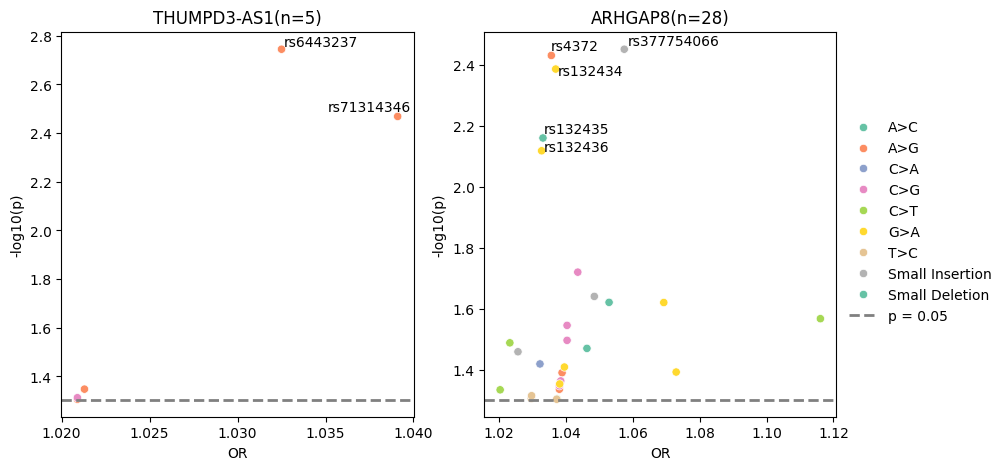

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, gene in enumerate(['THUMPD3-AS1', 'ARHGAP8']):
    ax = axes[i]
    df = GWAS_gene_snp_df[GWAS_gene_snp_df['Gene']==gene]
    sns.scatterplot(df, 
                    x='OR', y='-log10(p)', palette='Set2', #size=1,
                hue='SNP Type', ax=ax, 
                hue_order=['A>C', 'A>G', 'C>A', 'C>G', 'C>T', 'G>A', 'T>C', 
                           'Small Insertion', 'Small Deletion'])
    # Calculate y = -log10(0.05)
    threshold = -np.log10(0.05)

    # Add Horizontal Line
    ax.set_title(f'{gene}(n={gene_count[gene]})')
    ax.axhline(y=threshold, color='gray', linestyle='--', linewidth=2, label=f"p = 0.05")
    #ax.xticks(rotation=10)

    # Create text labels
    texts = []
    data = df[df['-log10(p)'] > 2]
    for i in range(len(data)):
        texts.append(ax.text(data['OR'].iloc[i], data['-log10(p)'].iloc[i], data['SNP'].iloc[i], fontsize=10))

    print(texts)
    # Adjust the positions of the texts to prevent overlap
    adjust_text(texts, ax=ax)


# Get handles and labels from both plots
handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
axes[0].legend().remove()
axes[1].legend().remove()


# Combine handles and labels, ensuring no duplicates
handles = handles1 + handles2
labels = labels1 + labels2
unique_handles_labels = dict(zip(labels, handles))

# Add common legend
fig.legend(unique_handles_labels.values(), unique_handles_labels.keys(), 
           loc='center left', bbox_to_anchor=(0.9, 0.5), ncol=1, frameon=False)
# Adjust spacing
#plt.tight_layout()
fig.savefig('GWAS.pdf', format='pdf')
plt.show()
